# Simple Linear Regression

## Import relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import joblib
sns.set()

## Load the data

In [2]:
data = pd.read_excel('Test_Grade_Gender.xlsx')

In [3]:
data

,TESTRESULT,GRADE,GENDER
0,1714,2.40,M
1,1664,2.52,M
2,1760,2.54,M
3,1685,2.74,M
4,1693,2.83,M
...,...,...,...
79,1936,3.71,F
80,1810,3.71,F
81,1987,3.73,F
82,1962,3.76,F


## Deskriptive Statistik

In [4]:
data.describe()

,TESTRESULT,GRADE
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


## Simple Linear Regression

Develop a Simple Linear Regression with TESTRESULT as single feature and GRADE as Target

### Explain Python the Feature and Target

In [5]:
y = data['GRADE']
x1 = data['TESTRESULT']

## Visualization

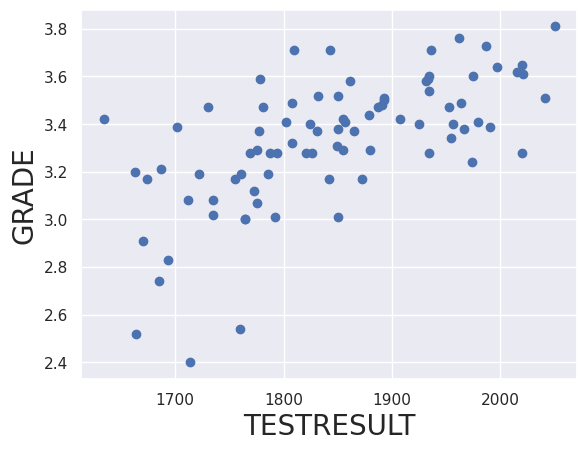

In [6]:
plt.scatter(x1,y)
plt.xlabel('TESTRESULT', fontsize=20)
plt.ylabel('GRADE', fontsize=20)
plt.show()

## Regression Model

In [7]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  GRADE   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           7.20e-11
Time:                        14:02:42   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.503      -0.538       1.088
TESTRESULT     0.0017      0.000      7.487      0.000       0.001       0.002
==============================================================================
Omnibus:                       12.839   Durbin-Watson:                   0.950
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.155
Skew:                          -0.722   Prob(JB):                     0.000310
Kurtosis:                       4.590   Cond. No.                     3.29e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Visualization of Regression Line

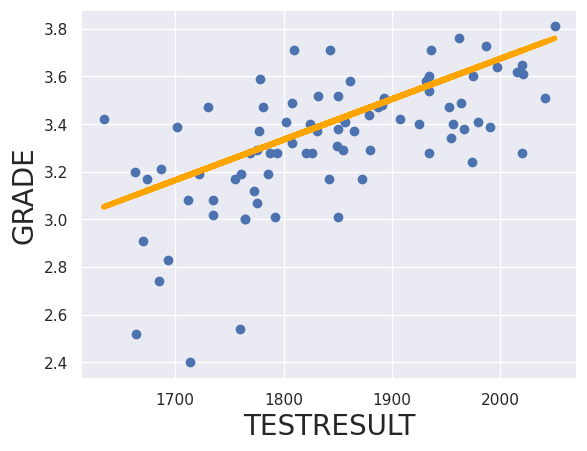

In [8]:
plt.scatter(x1,y)
yhat = 0.0017*x1 + 0.2750
fig = plt.plot(x1,yhat,lw=4,c='orange', label='regression line')
plt.xlabel('TESTRESULT', fontsize=20)
plt.ylabel('GRADE', fontsize=20)
plt.show()

## Prepare Deployment of the Model

In [9]:
joblib.dump(results, "results.pkl")
print("Model safed.")

Model safed.


## ML Model als API deployen (FastAPI) ##

- FastAPI-Endpunkt erstellen
- Erstelle eine Datei app.py im selben Verzeichnis wie results.pkl

In [10]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np
import statsmodels.api as sm

app = FastAPI()
model = joblib.load("results.pkl")

class Features(BaseModel):
    TESTRESULT: float

@app.post("/predict")
def predict(data: Features):
    X = sm.add_constant([[data.TESTRESULT]], has_constant='add')
    prediction = model.predict(X)[0]
    return {
        "prediction": round(float(prediction), 3)
    }

Overwriting app.py


## Prepare further Deployment ##

- Further deployment is working with railway.app
- Railway is demanding three files in a GitHub Repo: 1) app.py, 2) model.pkl, 3) requirements.text
- Requirements should contain the required libraries for the ML model